In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read in the data set
df = pd.read_csv('covid_data.csv')

In [2]:
print("--- Initial Dataset Shape ---")
print(df.shape)

print("\n--- Column Information ---")
print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe())

--- Initial Dataset Shape ---
(228983, 67)

--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 228983 entries, 0 to 228982
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    228983 non-null  str    
 1   continent                                   216050 non-null  str    
 2   location                                    228983 non-null  str    
 3   date                                        228983 non-null  str    
 4   total_cases                                 215997 non-null  float64
 5   new_cases                                   215741 non-null  float64
 6   new_cases_smoothed                          214545 non-null  float64
 7   total_deaths                                196813 non-null  float64
 8   new_deaths                                  196763 non-null  float64
 9   new_deaths

In [3]:
print("--- Starting Preprocessing ---")

limit = len(df) * 0.4
df = df.dropna(thresh=limit, axis=1)

df = df.dropna()

df = df.drop(columns=[c for c in df.columns if 'smoothed' in c])

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("--- Preprocessing Complete ---")
print(f"Final Shape: {df.shape}")
print(f"Remaining Missing Values: {df.isnull().sum().sum()}")

--- Starting Preprocessing ---
--- Preprocessing Complete ---
Final Shape: (34652, 30)
Remaining Missing Values: 0


--- Step 4: High-Level Worldwide Charts ---


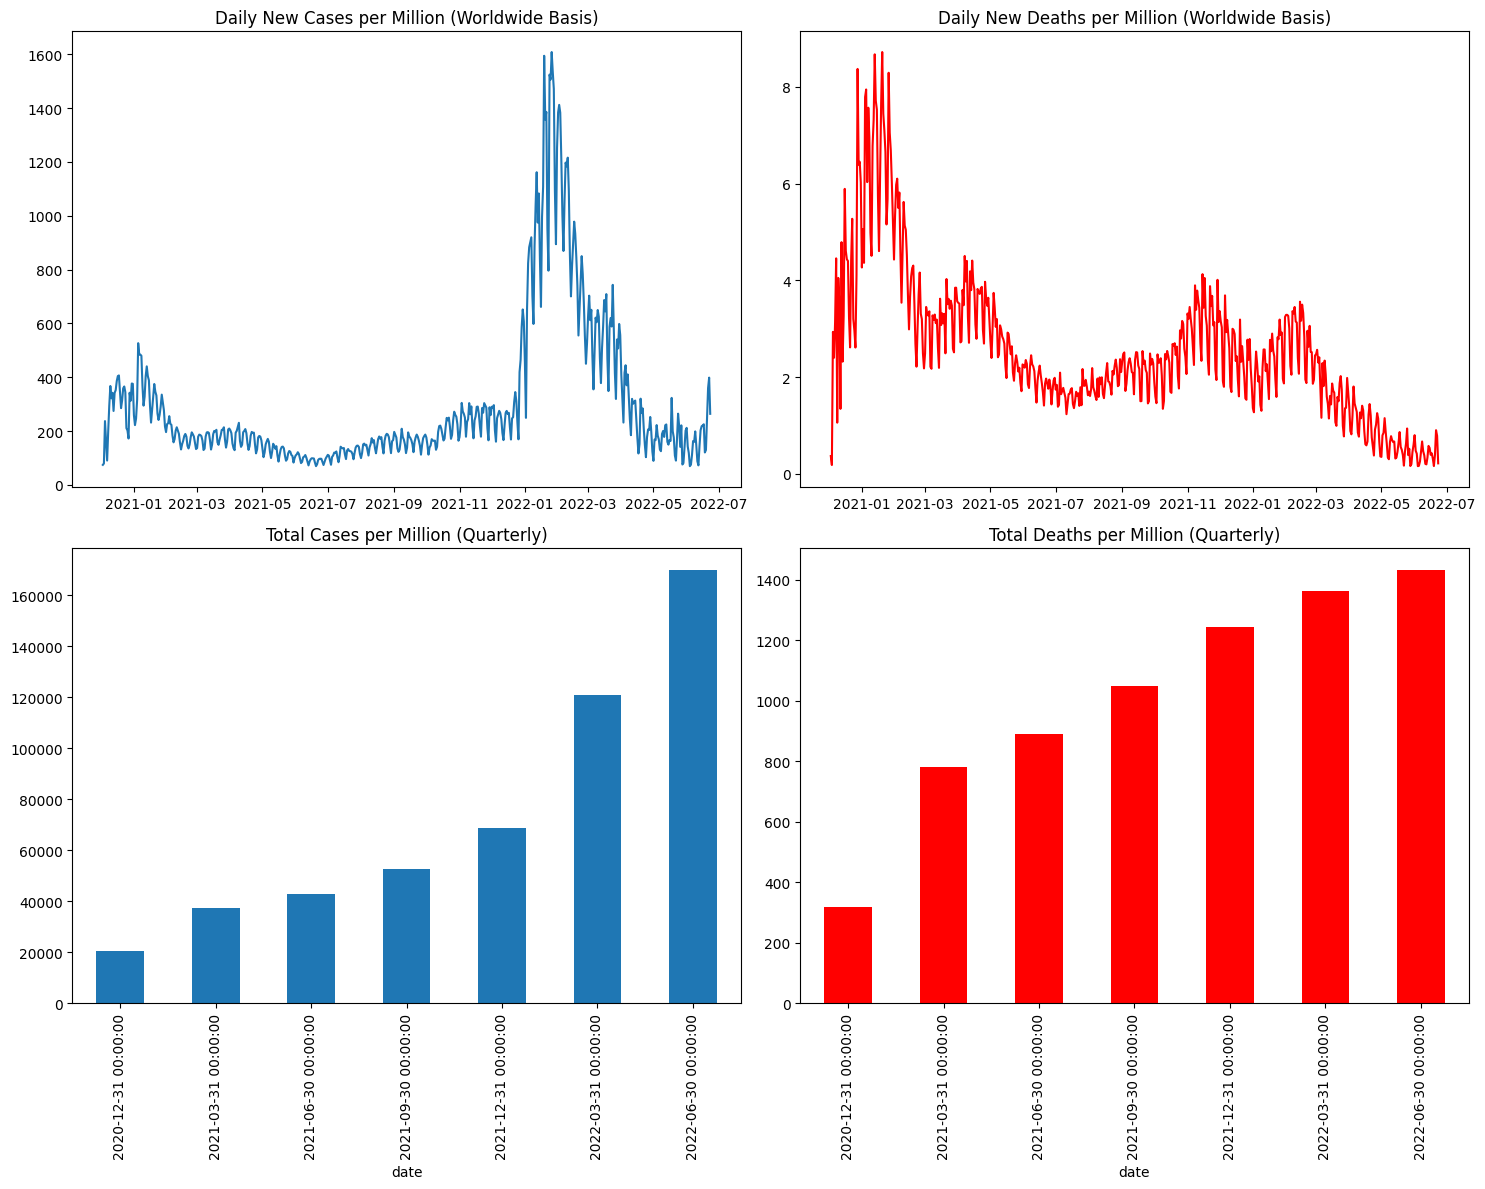

In [7]:
print("--- Step 4: High-Level Worldwide Charts ---")

world_df = df.groupby(level=0).mean(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].plot(world_df.index, world_df['new_cases_per_million'])
axes[0, 0].set_title('Daily New Cases per Million (Worldwide Basis)')

axes[0, 1].plot(world_df.index, world_df['new_deaths_per_million'], color='red')
axes[0, 1].set_title('Daily New Deaths per Million (Worldwide Basis)')

world_df['total_cases_per_million'].resample('QE').mean().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Total Cases per Million (Quarterly)')

world_df['total_deaths_per_million'].resample('QE').mean().plot(kind='bar', ax=axes[1, 1], color='red')
axes[1, 1].set_title('Total Deaths per Million (Quarterly)')

plt.tight_layout()
plt.show()

--- Generating Country Comparison Chart ---


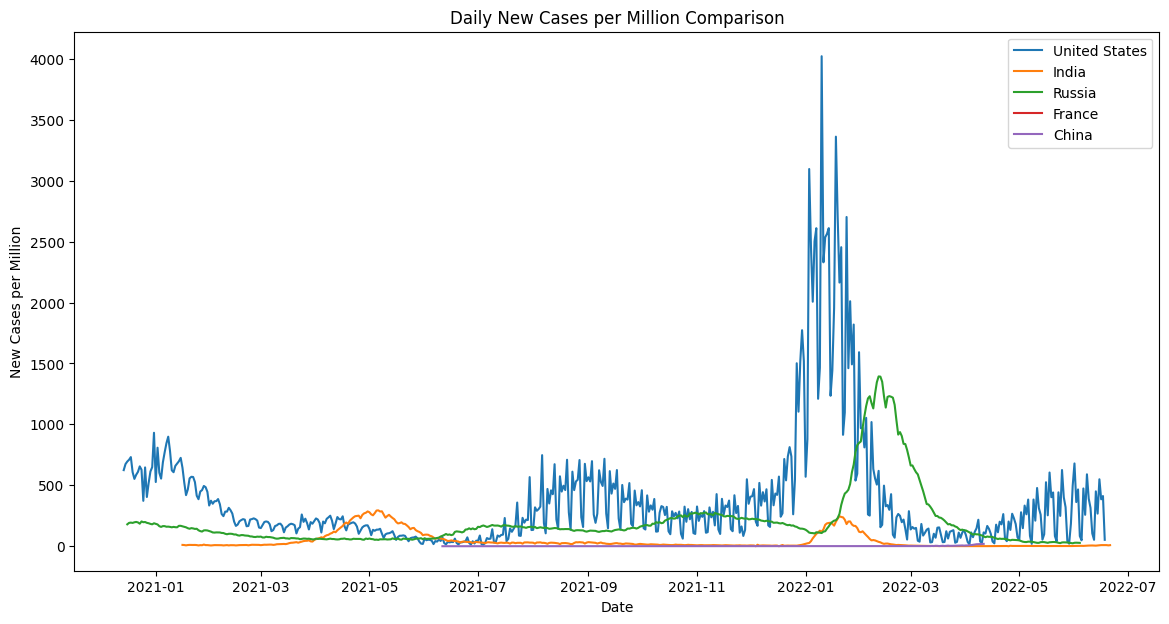

In [8]:
print("--- Generating Country Comparison Chart ---")

plt.figure(figsize=(14, 7))
countries = ['United States', 'India', 'Russia', 'France', 'China']

for country in countries:
    subset = df[df['location'] == country]
    plt.plot(subset.index, subset['new_cases_per_million'], label=country)

plt.title('Daily New Cases per Million Comparison')
plt.xlabel('Date')
plt.ylabel('New Cases per Million')
plt.legend()
plt.show()

--- Generating ISO Code Bar Charts ---
Plotting Total Cases by Country Code...


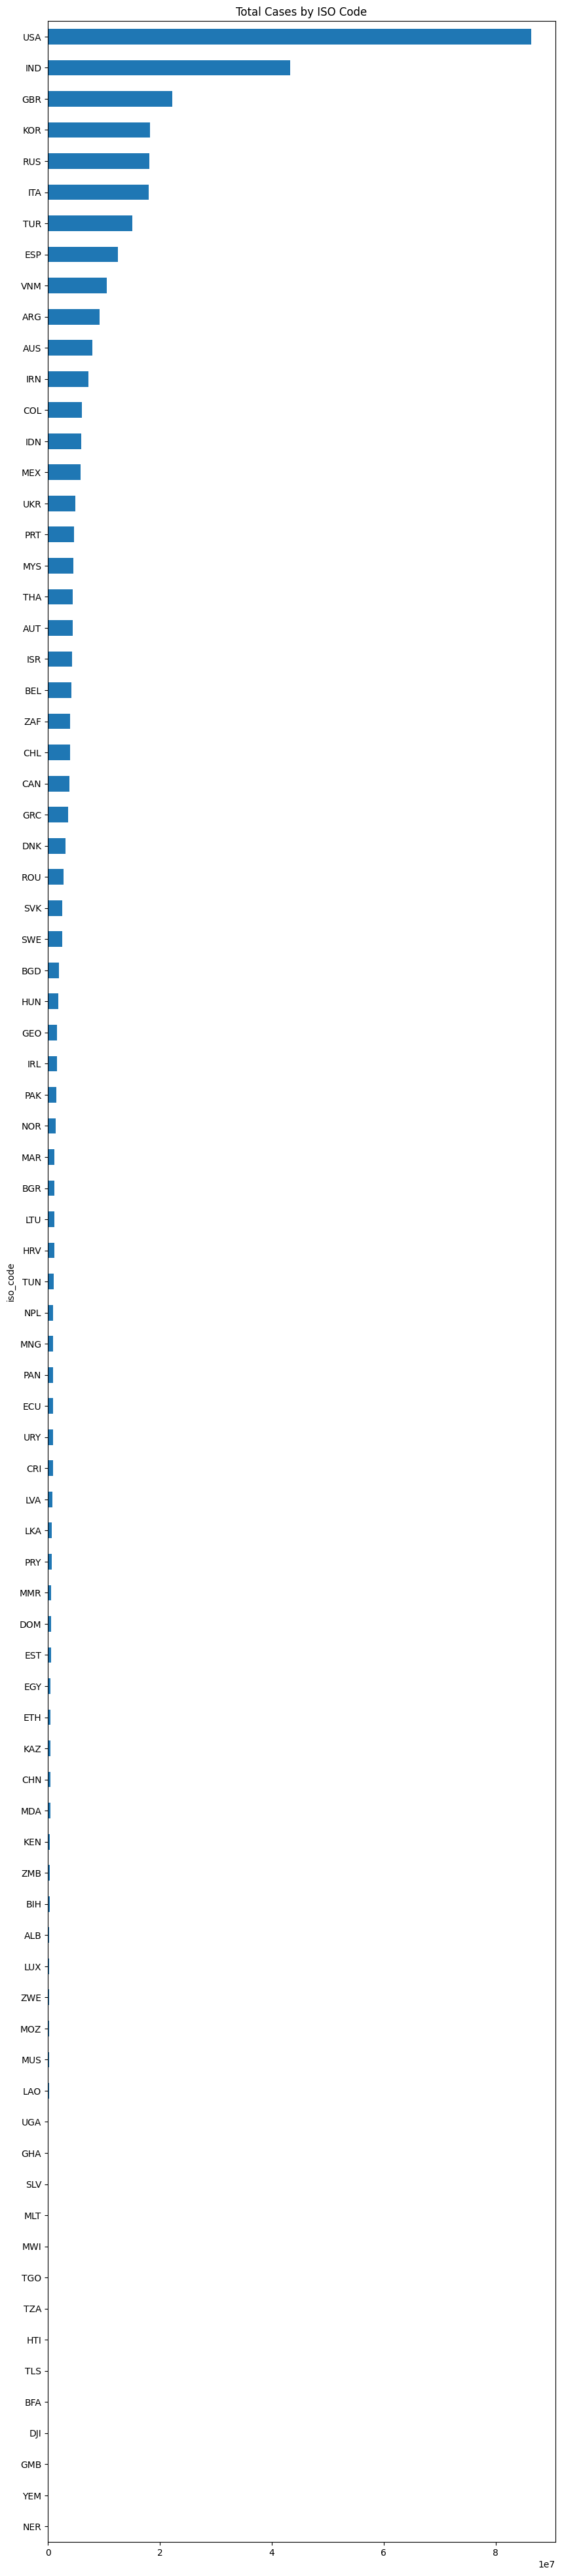

Plotting Total Deaths by Country Code...


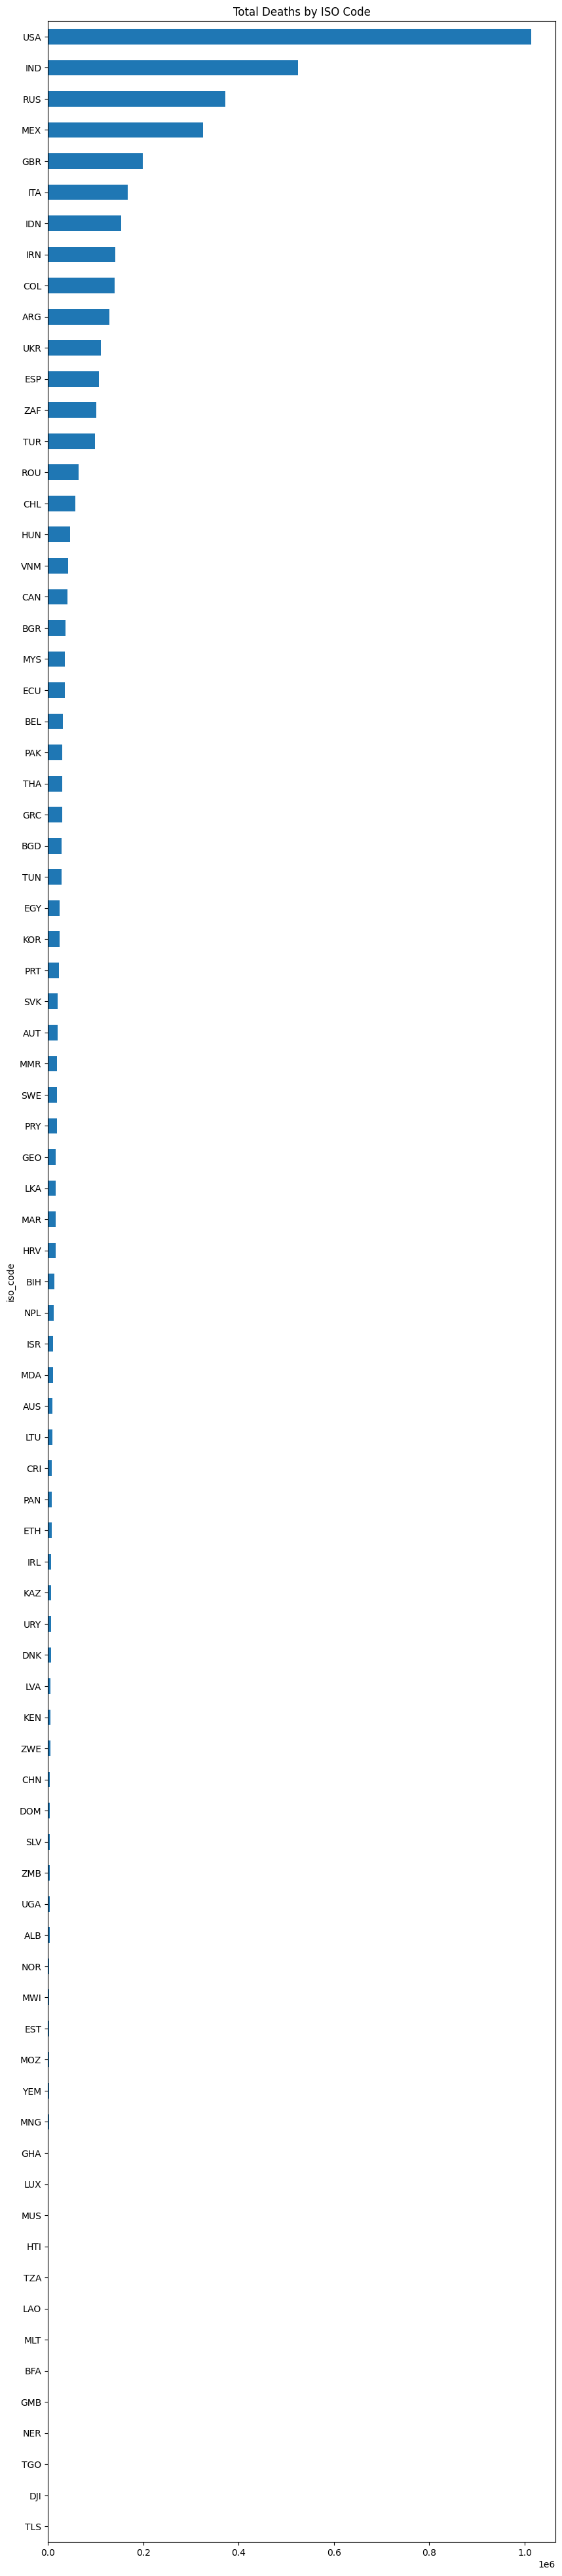

In [9]:
print("--- Generating ISO Code Bar Charts ---")

grouped = df.groupby('iso_code').max()

print("Plotting Total Cases by Country Code...")
grouped['total_cases'].sort_values().plot(kind='barh', figsize=(10, 50))
plt.title('Total Cases by ISO Code')
plt.show()

print("Plotting Total Deaths by Country Code...")
grouped['total_deaths'].sort_values().plot(kind='barh', figsize=(10, 50))
plt.title('Total Deaths by ISO Code')
plt.show()